In [1]:
import os

from dataset import *
from gpr import *
from train import *
from ace_extractor import *
from calculator import *
from plot import *
from dataset_analysis import *

import torch
from ase.io import read

# Dataset

In [2]:
dirlist_ontop = sorted(
    s for s in os.listdir('../seminar/dataset_ads/Run_1_250_seed13_clean_TOP/')
    if s.startswith('alloy')
)

slab_co_ontop_atoms = [read(f'../seminar/dataset_ads/Run_1_250_CO_same_place_TOP/{i}_CO/OUTCAR') for i in dirlist_ontop]
slab_co_ontop_energy = [slab_co_ontop_atoms[i].get_potential_energy() for i in range(len(slab_co_ontop_atoms))]

slab_ontop_atoms = [read(f'../seminar/dataset_ads/Run_1_250_seed13_clean_TOP/{i}/OUTCAR') for i in dirlist_ontop]
slab_ontop_energy = [slab_ontop_atoms[i].get_potential_energy() for i in range(len(slab_ontop_atoms))]

dirlist_bridge = sorted(
    s for s in os.listdir('../seminar/dataset_ads/Run_1_250_seed13/')
    if s.startswith('alloy')
)

slab_co_bridge_atoms = [read(f'../seminar/dataset_ads/Run_1_250_CO_bridge/{i}_CO/OUTCAR') for i in dirlist_bridge]
slab_co_bridge_energy = [slab_co_bridge_atoms[i].get_potential_energy() for i in range(len(slab_co_bridge_atoms))]

slab_bridge_atoms = [read(f'../seminar/dataset_ads/Run_1_250_seed13/{i}/OUTCAR') for i in dirlist_bridge]
slab_bridge_energy = [slab_bridge_atoms[i].get_potential_energy() for i in range(len(slab_bridge_atoms))]

co_energy = torch.tensor(read('/Users/oq7884/Documents/for_Danila/seminar/dataset_ads/CO_gase/OUTCAR').get_potential_energy())

target_y = torch.tensor( slab_co_ontop_energy + slab_co_bridge_energy ) - ( torch.tensor(slab_ontop_energy + slab_bridge_energy) + co_energy )

At "On-top" dataset there are Pt on-top (-1.7 eV), Pd on-top (-1.3) and Pd bridge (-1.7)

In [3]:
target_y[:4]

tensor([-1.6554, -1.6984, -1.2502, -1.6578])

In [4]:
from ase.visualize import view
#view(slab_co_ontop_atoms[:4], 'x3d')

In [5]:
atoms = []
atom_indices = []

for atom in slab_co_ontop_atoms + slab_co_bridge_atoms:
    _atoms, _atom_indices = atoms_near_carbon(atom)
    atoms.append(_atoms)
    atom_indices.append(_atom_indices)

# Configuration, Feature Extractor and Model Initiation

In [6]:
config = ACEConfig(
    elements=("Pd", "Pt"),
    max_order = 3,
    mindist=calc_mindist(atoms[0]),
    shells=(0, 1.2, np.sqrt(2.6), np.sqrt(3.6), 2.2),
)

In [7]:
extractor = ClusterExpansion(config)

In [8]:
#mask = [len(atom_indices[i]) == 1 for i in range(len(atom_indices))]

#indices = [i for i in range(len(atom_indices)) if len(atom_indices[i]) == 1]

In [9]:
dataset = ACEDataset(
    atoms = atoms,
    config = config,
    extractor = extractor,
    atom_indices = atom_indices,
    target_y = target_y,
)

100%|██████████| 484/484 [00:02<00:00, 186.89it/s]
/Users/oq7884/Documents/for_Danila/seminar3/dataset.py:74: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_dataset = torch.tensor(self.target_y, dtype=self.dtype)


In [10]:
train_dataset, valid_dataset = train_valid_split(dataset,
                                                 train_fraction=0.8,
                                                 seed=45022
                                                 )

train_x, train_y = get_tensors_from_subset(train_dataset)
valid_x, valid_y = get_tensors_from_subset(valid_dataset)

Sum up atomwise descriptors of the same adsorbtion site

In [11]:
train_x = [x.sum(dim=0, keepdim=True) for x in train_x]
valid_x = [x.sum(dim=0, keepdim=True) for x in valid_x]

In [12]:
model = SparseAtomicGPR(x_train=train_x,
                        M=450,
                        div=0.0001,
                        init_lengthscale=3.0,
                        init_sigma2=1e-4,
                        init_outputscale = 3.0,
                        config=config,
                      )

100%|██████████| 386/386 [00:00<00:00, 554.57it/s] 

Selected 166 inducing points out of 450


# Training

In [15]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-1)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=20,
)

In [16]:
history, best_rmse = train_sparse_atomic_gpr(
    train_x=train_x,
    train_y=train_y,
    valid_x=valid_x,
    valid_y=valid_y,
    optimizer=optimizer,
    scheduler=scheduler,
    model=model,
    n_epochs=201,
    model_path="sparse_atomic_gpr_ads.pt",
    device=torch.device("cpu"),
)

Iter 1/201 RMSE train: 0.020441 RMSE valid: 0.041351 MAE train: 0.015975 MAE valid: 0.029780 best RMSE valid: 0.041351 sigma2: 5.577e-05 ls_mean: 2.088e+01 outputscale: 5.379e+00 lr: 1.000e-01
Iter 51/201 RMSE train: 0.008514 RMSE valid: 0.018209 MAE train: 0.006596 MAE valid: 0.013988 best RMSE valid: 0.017977 sigma2: 1.802e-05 ls_mean: 7.471e+01 outputscale: 1.665e+01 lr: 1.000e-01
Iter 101/201 RMSE train: 0.008315 RMSE valid: 0.018302 MAE train: 0.006443 MAE valid: 0.014217 best RMSE valid: 0.017977 sigma2: 1.439e-05 ls_mean: 8.430e+01 outputscale: 2.085e+01 lr: 2.500e-02
Iter 151/201 RMSE train: 0.008279 RMSE valid: 0.018340 MAE train: 0.006406 MAE valid: 0.014279 best RMSE valid: 0.017977 sigma2: 1.401e-05 ls_mean: 8.698e+01 outputscale: 2.141e+01 lr: 3.125e-03
Iter 201/201 RMSE train: 0.008271 RMSE valid: 0.018348 MAE train: 0.006396 MAE valid: 0.014294 best RMSE valid: 0.017977 sigma2: 1.394e-05 ls_mean: 8.758e+01 outputscale: 2.151e+01 lr: 7.813e-04


In [17]:
K_NM = model.build_K_NM(train_x)

print("K_NM shape:", K_NM.shape)
print("rank:", torch.linalg.matrix_rank(K_NM).item())
print("cond:", torch.linalg.cond(K_NM.T @ K_NM).item())

K_NM shape: torch.Size([387, 166])
rank: 166
cond: 2376959387866.8105


# Results

In [18]:
model = SparseAtomicGPR(model_path = 'sparse_atomic_gpr_ads.pt')

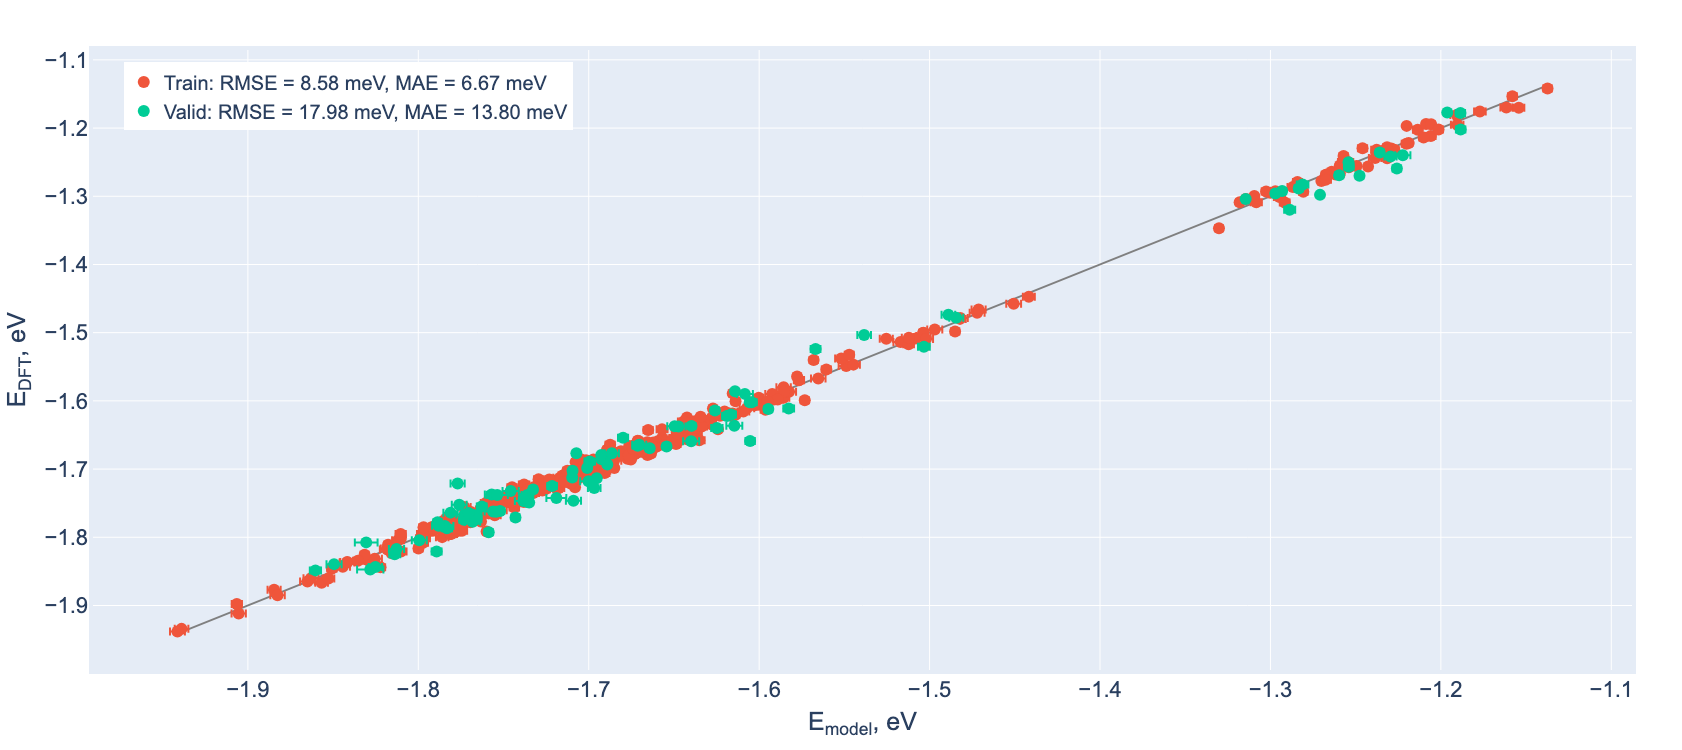

In [19]:
fig, metrics = plot_results(
    model,
    train_x,
    train_y,
    valid_x,
    valid_y,
)

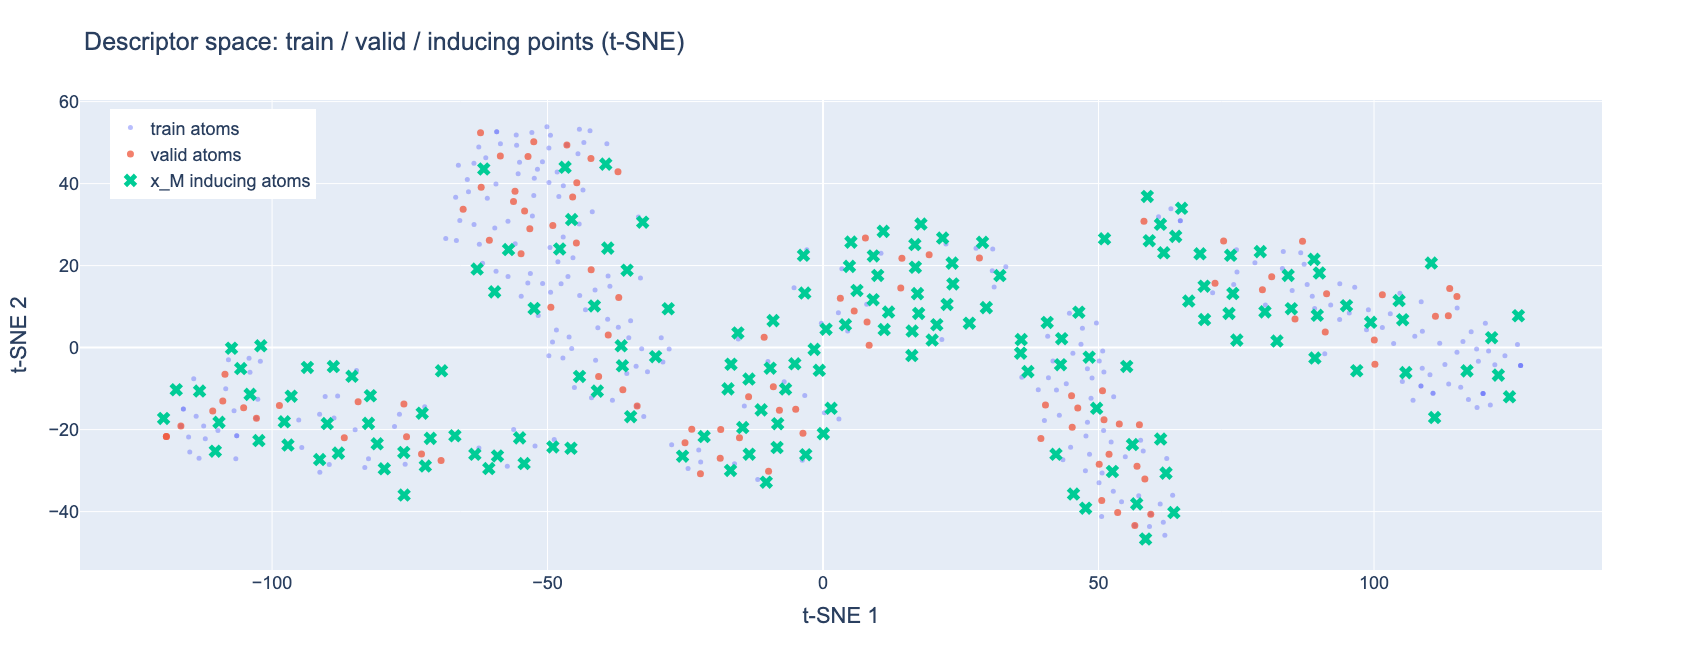

In [24]:
fig, X_emb, labels = plot_descriptor_space(
    model,
    train_x,
    valid_x)

In [31]:
model([train_x[0]])

tensor([-1.7608], dtype=torch.float64, grad_fn=<MvBackward0>)

In [33]:
test = read('structure_mc.xyz')

In [34]:
des = extractor(test, [117])

In [35]:
model([des])

tensor([-1.3038], dtype=torch.float64, grad_fn=<MvBackward0>)

In [37]:
view(test, 'x3d')

<Popen: returncode: None args: ['/opt/anaconda3/envs/ace_gpr/bin/python', '-...>